In this project, I will build machine learning and deep learning models to classify images as either AI generated or real images.

### **Required Libraries**

In [11]:
!pip uninstall -y jax jaxlib

In [12]:
# Data handling
import kagglehub
import os
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Deep Learning
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
Conv2D,
MaxPooling2D,
Flatten,
Dense,
Dropout)

NOTE: A compatibility issue between TensorFlow and JAX was resolved by removing conflicting dependencies, ensuring stable model training.

### **Task 1.1** — Load and Explore

Dataset path: /kaggle/input/datasets/cashbowman/ai-generated-images-vs-real-images
First few rows:                                           Image_Name  \
0  portrait-smiling-middle-aged-african-260nw-208...   
1                A142xwh4GVL._AC_UF8941000_QL80_.jpg   
2  -man-sits-with-a-woman-on-her-phone-at-a-table...   
3                       people-strategy_1200x700.jpg   
4  360_F_606797008_rGPPk6bFWDQydnX7g7w1w9dVVZ4mD2...   

                                          Image_Path Category  Label  
0  /kaggle/input/datasets/cashbowman/ai-generated...  RealArt      0  
1  /kaggle/input/datasets/cashbowman/ai-generated...  RealArt      0  
2  /kaggle/input/datasets/cashbowman/ai-generated...  RealArt      0  
3  /kaggle/input/datasets/cashbowman/ai-generated...  RealArt      0  
4  /kaggle/input/datasets/cashbowman/ai-generated...  RealArt      0  
Shape: (970, 4)

Null values:
 Image_Name    0
Image_Path    0
Category      0
Label         0
dtype: int64

Duplicates: 0


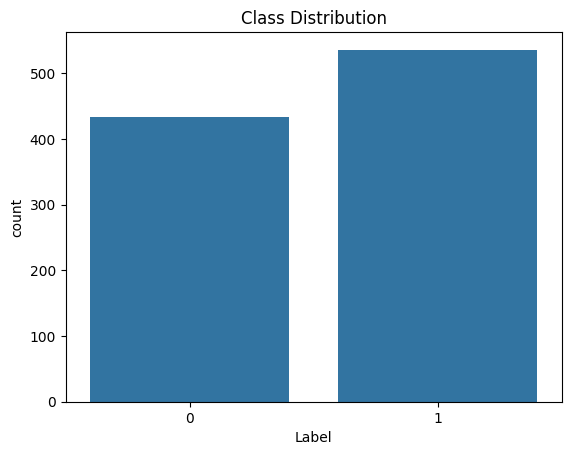

In [13]:
# Download dataset
path = kagglehub.dataset_download("cashbowman/ai-generated-images-vs-real-images")
print("Dataset path:", path)
base_path = path


# Create DataFrame
def create_dataframe(base_path):
    data = []

    for category in os.listdir(base_path):
        category_path = os.path.join(base_path, category)

        if os.path.isdir(category_path):
            label = 1 if "ai" in category.lower() else 0

            for sub in os.listdir(category_path):
                sub_path = os.path.join(category_path, sub)

                if os.path.isdir(sub_path):
                    for img_name in os.listdir(sub_path):

                        if img_name.lower().endswith(('.png','.jpg','.jpeg')):
                            img_path = os.path.join(sub_path, img_name)

                            data.append([img_name, img_path, category, label])

    df = pd.DataFrame(data, columns=["Image_Name", "Image_Path", "Category", "Label"])
    return df

df = create_dataframe(base_path)

# Explore
def explore_data(df):
   # Check first rows
   print("First few rows:", df.head())
   # Check shape
   print("Shape:", df.shape)
   # Check missing values
   print("\nNull values:\n", df.isnull().sum())
   # Check duplicate
   print("\nDuplicates:", df.duplicated().sum())

   # Check class balance
   sns.countplot(x=df["Label"])
   plt.title("Class Distribution")
   plt.show()
explore_data(df)

NOTE: Since the dataset is relatively balanced, both Accuracy and F1-score are suitable evaluation metrics. 
However, F1-score is still considered for a more reliable assessment of model performance.

### **Task 1.2** — Prepare the Data

In [14]:
def load_images(base_path):
    images = []
    labels = []

    classes = os.listdir(base_path)

    for label, folder in enumerate(classes):
        folder_path = os.path.join(base_path, folder)

        if os.path.isdir(folder_path):
            for subfolder in os.listdir(folder_path):
                subfolder_path = os.path.join(folder_path, subfolder)

                if os.path.isdir(subfolder_path):
                    for img_name in os.listdir(subfolder_path):

                        if img_name.lower().endswith(('.png','.jpg','.jpeg')):

                            img_path = os.path.join(subfolder_path, img_name)

                            try:
                                img = plt.imread(img_path)
                                img = np.resize(img, (16,16,3))

                                images.append(img)
                                labels.append(label)

                            except:
                                continue

    return np.array(images), np.array(labels)

# Load dataset
X, y = load_images(base_path)

print("X shape:", X.shape)
print("y shape:", y.shape)

# Normalize pixel values to [0,1]
def normalize_data(X):
  return X / 255.0
X = normalize_data(X)

def split_data(X, y):
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42, stratify=y
    )

  # Print shapes of datasets
  print("X_train shape:", X_train.shape)
  print("X_test shape:", X_test.shape)
  print("y_train shape:", y_train.shape)
  print("y_test shape:", y_test.shape)

  return X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = split_data(X, y)

X shape: (959, 16, 16, 3)
y shape: (959,)
X_train shape: (767, 16, 16, 3)
X_test shape: (192, 16, 16, 3)
y_train shape: (767,)
y_test shape: (192,)


### **Task 1.3** — Train and Compare Machine Learning Models


Logistic Regression Results:
Accuracy: 0.609375
Precision: 0.6347826086956522
Recall: 0.6886792452830188
F1 score: 0.6606334841628959


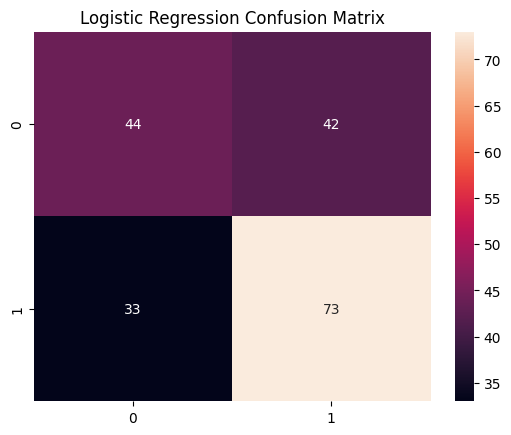


Random Forest Results:
Accuracy: 0.6197916666666666
Precision: 0.6633663366336634
Recall: 0.6320754716981132
F1 score: 0.6473429951690821


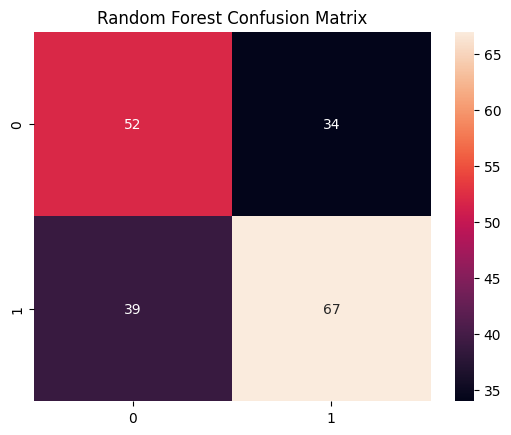


KNN Results:
Accuracy: 0.6041666666666666
Precision: 0.6415094339622641
Recall: 0.6415094339622641
F1 score: 0.6415094339622641


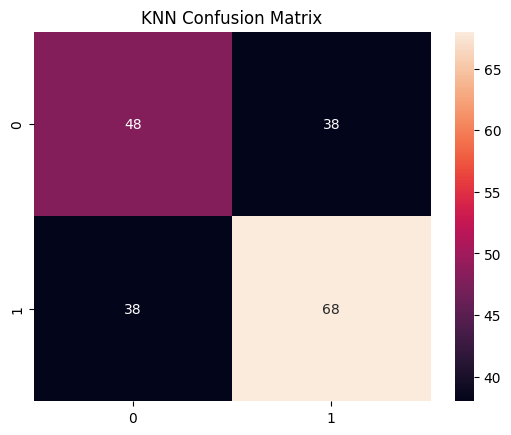

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.609375   0.634783  0.688679  0.660633
1        Random Forest  0.619792   0.663366  0.632075  0.647343
2                  KNN  0.604167   0.641509  0.641509  0.641509


In [15]:
# Flatten images for ML models
def flatten(X_train, X_test):
    return X_train.reshape(X_train.shape[0], -1), X_test.reshape(X_test.shape[0], -1)
X_train_flat, X_test_flat = flatten(X_train, X_test)

# Evaluate model performance
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{name} Results:")
    print("Accuracy:", acc)
    print("Precision:", pre)
    print("Recall:", rec)
    print("F1 score:", f1)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    return [name, acc, pre, rec, f1]

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_flat, y_train)
lr_results = evaluate_model(lr, X_test_flat, y_test, "Logistic Regression")

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train_flat, y_train)
rf_results = evaluate_model(rf, X_test_flat, y_test, "Random Forest")

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_flat, y_train)
knn_results = evaluate_model(knn, X_test_flat, y_test, "KNN")

# Summary Table
results_table = pd.DataFrame(
    [lr_results, rf_results, knn_results],
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"]
)

print(results_table)

NOTE: Among the three classical machine learning models, **Logistic Regression achieved the best overall performance** based on the most reliable evaluation metric.

Although Random Forest obtained the highest Accuracy (61%), Accuracy alone may not fully reflect model performance. Since the dataset is relatively balanced, both Accuracy and F1-score are appropriate metrics; however, F1-score is considered more reliable as it balances both Precision and Recall.

Logistic Regression achieved the highest F1-score (66%) and Recall (68%), indicating that it was more effective in correctly identifying positive cases while maintaining a good balance between Precision and Recall.

K-Nearest Neighbors (KNN) showed stable and balanced performance across all metrics, but did not outperform the other models.

Therefore, Logistic Regression was selected as the best performing model in this project based on its superior F1-score, demonstrating a more reliable and balanced performance compared to the other models.

### **Task 2.1** — Neural Network

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-31 21:16:42.356883: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5632 - loss: 0.6891 - val_accuracy: 0.5521 - val_loss: 0.6865
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5684 - loss: 0.6820 - val_accuracy: 0.6302 - val_loss: 0.6578
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6050 - loss: 0.6566 - val_accuracy: 0.6354 - val_loss: 0.6577
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6115 - loss: 0.6523 - val_accuracy: 0.6198 - val_loss: 0.6571
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5906 - loss: 0.6496 - val_accuracy: 0.6458 - val_loss: 0.6619
Epoch 6/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6258 - loss: 0.6464 - val_accuracy: 0.6458 - val_loss: 0.6594
Epoch 7/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6349 - loss: 0.6411 - val_accuracy: 0.6406 - val_loss: 0.6620
Epoch 8/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6362 - loss: 0.6360 - val_accuracy: 0.6562 - v

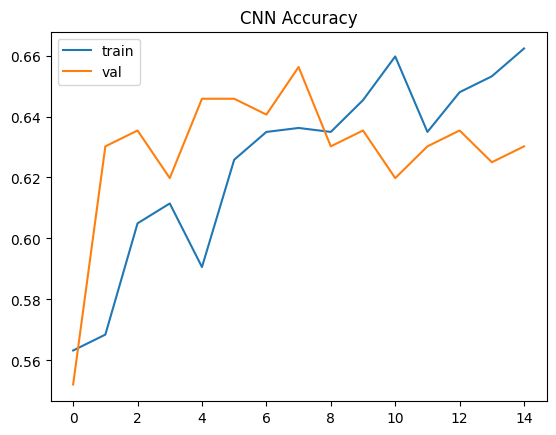

In [16]:
# Build CNN model for image classification.
def build_cnn():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(16,16,3)),
        MaxPooling2D(),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def train_cnn(model, X_train, y_train, X_test, y_test):
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=15, batch_size=32)
    return history

cnn_model = build_cnn()
history = train_cnn(cnn_model, X_train, y_train, X_test, y_test)


loss, cnn_acc = cnn_model.evaluate(X_test, y_test)
print("CNN Accuracy:", cnn_acc)

cnn_pred = (cnn_model.predict(X_test) > 0.5).astype(int)

cnn_prec = precision_score(y_test, cnn_pred)
cnn_rec = recall_score(y_test, cnn_pred)
cnn_f1 = f1_score(y_test, cnn_pred)

cnn_res = ["CNN", cnn_acc, cnn_prec, cnn_rec, cnn_f1]

# Plot training vs validation accuracy.
def plot_history(history):
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.legend()
    plt.title("CNN Accuracy")
    plt.show()
plot_history(history)

NOTE: The model shows a steady improvement in training accuracy over epochs, indicating that it is learning effectively from the training data. The validation accuracy also increases in the early stages, but then fluctuates slightly and remains lower than the training accuracy. This suggests mild overfitting, where the model performs better on training data than on unseen data, but the gap is not very large and the model still generalizes reasonably well.


### **Task 2.2** — Compare Results

In [17]:
def create_summary_table(lr, rf, knn, cnn_acc):
    cnn_row = ["CNN", cnn_acc, None, None, cnn_acc]

    df = pd.DataFrame(
        [lr, rf, knn, cnn_row],
        columns=["Model", "Accuracy", "Precision", "Recall", "F1"]
    )
    return df

summary_table = pd.DataFrame(
    [lr_results, rf_results, knn_results, cnn_res],
    columns=["Model", "Accuracy", "Precision", "Recall", "F1"]
)

print(summary_table)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.609375   0.634783  0.688679  0.660633
1        Random Forest  0.619792   0.663366  0.632075  0.647343
2                  KNN  0.604167   0.641509  0.641509  0.641509
3                  CNN  0.630208   0.657658  0.688679  0.672811


NOTE: After evaluating and comparing traditional machine learning models with a Convolutional Neural Network (CNN), the results show that the CNN achieved the **best** overall performance.

The CNN obtained the highest Accuracy (63%) and the highest F1-score (67%), indicating a better balance between precision and recall compared to the other models. It also achieved the highest Precision (65%) and a strong Recall (68%), matching Logistic Regression in recall but performing better overall in combined metrics.

Overall, the results demonstrate that CNN slightly outperforms traditional machine learning models in my project. This highlights the advantage of CNNs in capturing spatial features, even though the improvement is moderate due to the small image size (16×16), which limits feature richness for deep learning models.

### **Bonus** — Functions for Better Code Quality

First few rows:                                           Image_Name  \
0  portrait-smiling-middle-aged-african-260nw-208...   
1                A142xwh4GVL._AC_UF8941000_QL80_.jpg   
2  -man-sits-with-a-woman-on-her-phone-at-a-table...   
3                       people-strategy_1200x700.jpg   
4  360_F_606797008_rGPPk6bFWDQydnX7g7w1w9dVVZ4mD2...   

                                          Image_Path Category  Label  
0  /kaggle/input/datasets/cashbowman/ai-generated...  RealArt      0  
1  /kaggle/input/datasets/cashbowman/ai-generated...  RealArt      0  
2  /kaggle/input/datasets/cashbowman/ai-generated...  RealArt      0  
3  /kaggle/input/datasets/cashbowman/ai-generated...  RealArt      0  
4  /kaggle/input/datasets/cashbowman/ai-generated...  RealArt      0  
Shape: (970, 4)

Null values:
 Image_Name    0
Image_Path    0
Category      0
Label         0
dtype: int64

Duplicates: 0


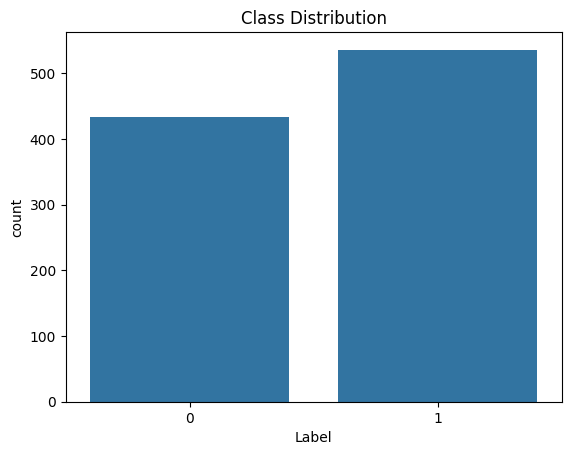

X_train shape: (767, 16, 16, 3)
X_test shape: (192, 16, 16, 3)
y_train shape: (767,)
y_test shape: (192,)

Logistic Regression Results:
Accuracy: 0.5520833333333334
Precision: 0.5520833333333334
Recall: 1.0
F1 score: 0.7114093959731543


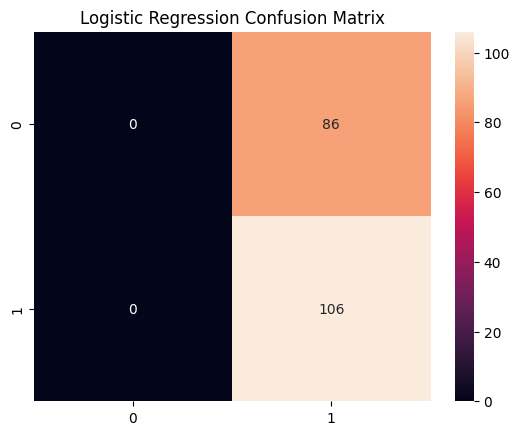


Random Forest Results:
Accuracy: 0.5989583333333334
Precision: 0.6407766990291263
Recall: 0.6226415094339622
F1 score: 0.631578947368421


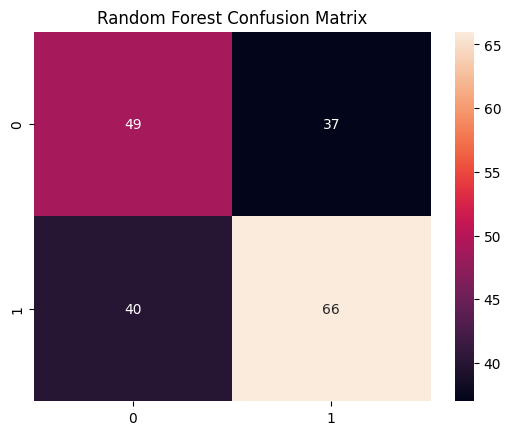


KNN Results:
Accuracy: 0.6041666666666666
Precision: 0.6415094339622641
Recall: 0.6415094339622641
F1 score: 0.6415094339622641


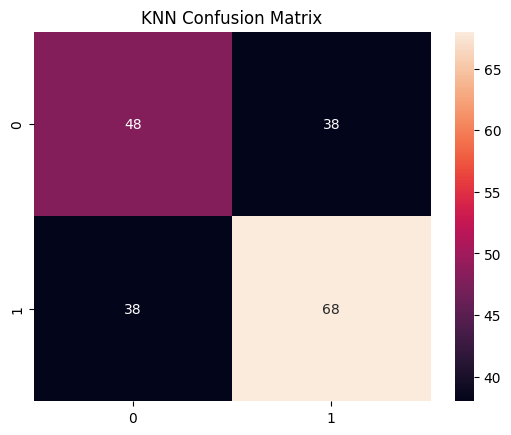

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5502 - loss: 0.6922 - val_accuracy: 0.5521 - val_loss: 0.6878
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5502 - loss: 0.6886 - val_accuracy: 0.5521 - val_loss: 0.6874
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5502 - loss: 0.6875 - val_accuracy: 0.5521 - val_loss: 0.6861
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5502 - loss: 0.6862 - val_accuracy: 0.5521 - val_loss: 0.6838
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5502 - loss: 0.6849 - val_accuracy: 0.5521 - val_loss: 0.6824
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5502 - loss: 0.6814 - val_accuracy: 0.5521 - val_loss: 0.6754
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5567 - loss: 0.6746 - val_accuracy: 0.6250 - val_loss: 0.6660
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6010 - loss: 0.6682 - val_accuracy: 0.6406 - val_loss: 0.

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.552083,0.552083,1.000000,0.711409
1,Random Forest,0.598958,0.640777,0.622642,0.631579
2,KNN,0.604167,0.641509,0.641509,0.641509
3,CNN,"[CNN, 0.6145833134651184, 0.6379310344827587, ...",NaN,NaN,"[CNN, 0.6145833134651184, 0.6379310344827587, ..."


In [19]:
# Main pipeline that runs all previous functions in order.
def pipeline():
    path = kagglehub.dataset_download("cashbowman/ai-generated-images-vs-real-images")
    base_path = path
    
    # Create dataframe
    df = create_dataframe(base_path)
    
    # Explore data
    explore_data(df)
    
    # Prepare data
    X, y = load_images(base_path)
    X = X / 255.0
    X = normalize_data(X)
    X_train, X_test, y_train, y_test = split_data(X, y)

    # Flatten images for ML models
    X_train_flat, X_test_flat = flatten(X_train, X_test)

    # ML Models
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train_flat, y_train)
    lr_results = evaluate_model(lr, X_test_flat, y_test, "Logistic Regression")

    rf = RandomForestClassifier()
    rf.fit(X_train_flat, y_train)
    rf_results = evaluate_model(rf, X_test_flat, y_test, "Random Forest")

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_flat, y_train)
    knn_results = evaluate_model(knn, X_test_flat, y_test, "KNN")

    # CNN
    model = build_cnn()
    model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10)

    loss, acc = model.evaluate(X_test, y_test)

    pred = (model.predict(X_test) > 0.5).astype(int)

    cnn_results = [
        "CNN",
        acc,
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ]

    # Create summary table
    summary_table = create_summary_table(
        lr_results,
        rf_results,
        knn_results,
        cnn_results
    )

    print("Pipeline finished")

    return summary_table

results = pipeline()
results